In [230]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.svm import SVC, SVR
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, mean_squared_error,
                             r2_score, classification_report)

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
np.random.seed(42)

# Load dataset
df = pd.read_csv('/content/bodyPerformance.csv')
print(f"Dataset Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:\n{df.head()}")

Dataset Shape: (13393, 12)

Columns: ['age', 'gender', 'height_cm', 'weight_kg', 'body fat_%', 'diastolic', 'systolic', 'gripForce', 'sit and bend forward_cm', 'sit-ups counts', 'broad jump_cm', 'class']

First 5 rows:
   age gender  height_cm  weight_kg  body fat_%  diastolic  systolic  \
0   27      M      172.3      75.24        21.3       80.0     130.0   
1   25      M      165.0      55.80        15.7       77.0     126.0   
2   31      M      179.6      78.00        20.1       92.0     152.0   
3   32      M      174.5      71.10        18.4       76.0     147.0   
4   28      M      173.8      67.70        17.1       70.0     127.0   

   gripForce  sit and bend forward_cm  sit-ups counts  broad jump_cm class  
0       54.9                     18.4            60.0          217.0     C  
1       36.4                     16.3            53.0          229.0     A  
2       44.8                     12.0            49.0          181.0     C  
3       41.4                     15.2   

In [231]:
#2.2 Column Understanding and Data Type Verification

In [232]:
df.describe()

,age,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm
count,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000
mean,36.775106,168.559807,67.447316,23.240165,78.796842,130.234817,36.963877,15.209268,39.771224,190.129627
std,13.625639,8.426583,11.949666,7.256844,10.742033,14.713954,10.624864,8.456677,14.276698,39.868000
min,21.000000,125.000000,26.300000,3.000000,0.000000,0.000000,0.000000,-25.000000,0.000000,0.000000
25%,25.000000,162.400000,58.200000,18.000000,71.000000,120.000000,27.500000,10.900000,30.000000,162.000000
50%,32.000000,169.200000,67.400000,22.800000,79.000000,130.000000,37.900000,16.200000,41.000000,193.000000
75%,48.000000,174.800000,75.300000,28.000000,86.000000,141.000000,45.200000,20.700000,50.000000,221.000000
max,64.000000,193.800000,138.100000,78.400000,156.200000,201.000000,70.500000,213.000000,80.000000,303.000000


In [233]:
# Data type verification
print("Data Types:")
print(df.dtypes)
print("\n" + "="*60)

# Check for column name consistency issues
print("\nColumn Names with Potential Issues:")
for col in df.columns:
    if ' ' in col:
        print(f"  - '{col}' contains spaces (may cause access issues)")

Data Types:
age                          int64
gender                      object
height_cm                  float64
weight_kg                  float64
body fat_%                 float64
diastolic                  float64
systolic                   float64
gripForce                  float64
sit and bend forward_cm    float64
sit-ups counts             float64
broad jump_cm              float64
class                       object
dtype: object


Column Names with Potential Issues:
  - 'body fat_%' contains spaces (may cause access issues)
  - 'sit and bend forward_cm' contains spaces (may cause access issues)
  - 'sit-ups counts' contains spaces (may cause access issues)
  - 'broad jump_cm' contains spaces (may cause access issues)


In [234]:
'''Data Type Analysis: The dataset contains 10 numeric features (float64) and 2 categorical features
 (gender, class - object).The column 'broad jump_cm' contains a space, which may cause attribute
access issues in some contexts; renaming is recommended.'''

"Data Type Analysis: The dataset contains 10 numeric features (float64) and 2 categorical features\n (gender, class - object).The column 'broad jump_cm' contains a space, which may cause attribute\naccess issues in some contexts; renaming is recommended."

In [235]:
#2.3 Missing Values Analysis

In [236]:
# Missing values analysis
missing_data = df.isnull().sum()
missing_percentage = (missing_data / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_data,
    'Missing Percentage': missing_percentage
})

print("Missing Values Analysis:")
print(missing_df[missing_df['Missing Count'] > 0] if missing_data.sum() > 0 else "No missing values found in any column.")

Missing Values Analysis:
No missing values found in any column.


In [237]:
'''Result: No missing values detected across any columns. This eliminates the need for imputation
strategies and preserves all 13,393 records for analysis.'''

'Result: No missing values detected across any columns. This eliminates the need for imputation\nstrategies and preserves all 13,393 records for analysis.'

In [238]:
#2.4 Duplicate Detection

In [239]:
# Duplicate detection
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

if duplicates > 0:
    print("\nDuplicate rows found. Removing duplicates...")
    df = df.drop_duplicates()
    print(f"New dataset shape: {df.shape}")
else:
    print("No duplicate rows detected.")

Number of duplicate rows: 1

Duplicate rows found. Removing duplicates...
New dataset shape: (13392, 12)


In [240]:
#Result: duplicate row was detected and removed, resulting in a final dataset of 13,393 unique records.

In [241]:
#2.6 Body Performance Analytics

numeric_cols (10): ['age', 'height_cm', 'weight_kg', 'body fat_%', 'diastolic', 'systolic', 'gripForce', 'sit and bend forward_cm', 'sit-ups counts', 'broad jump_cm']


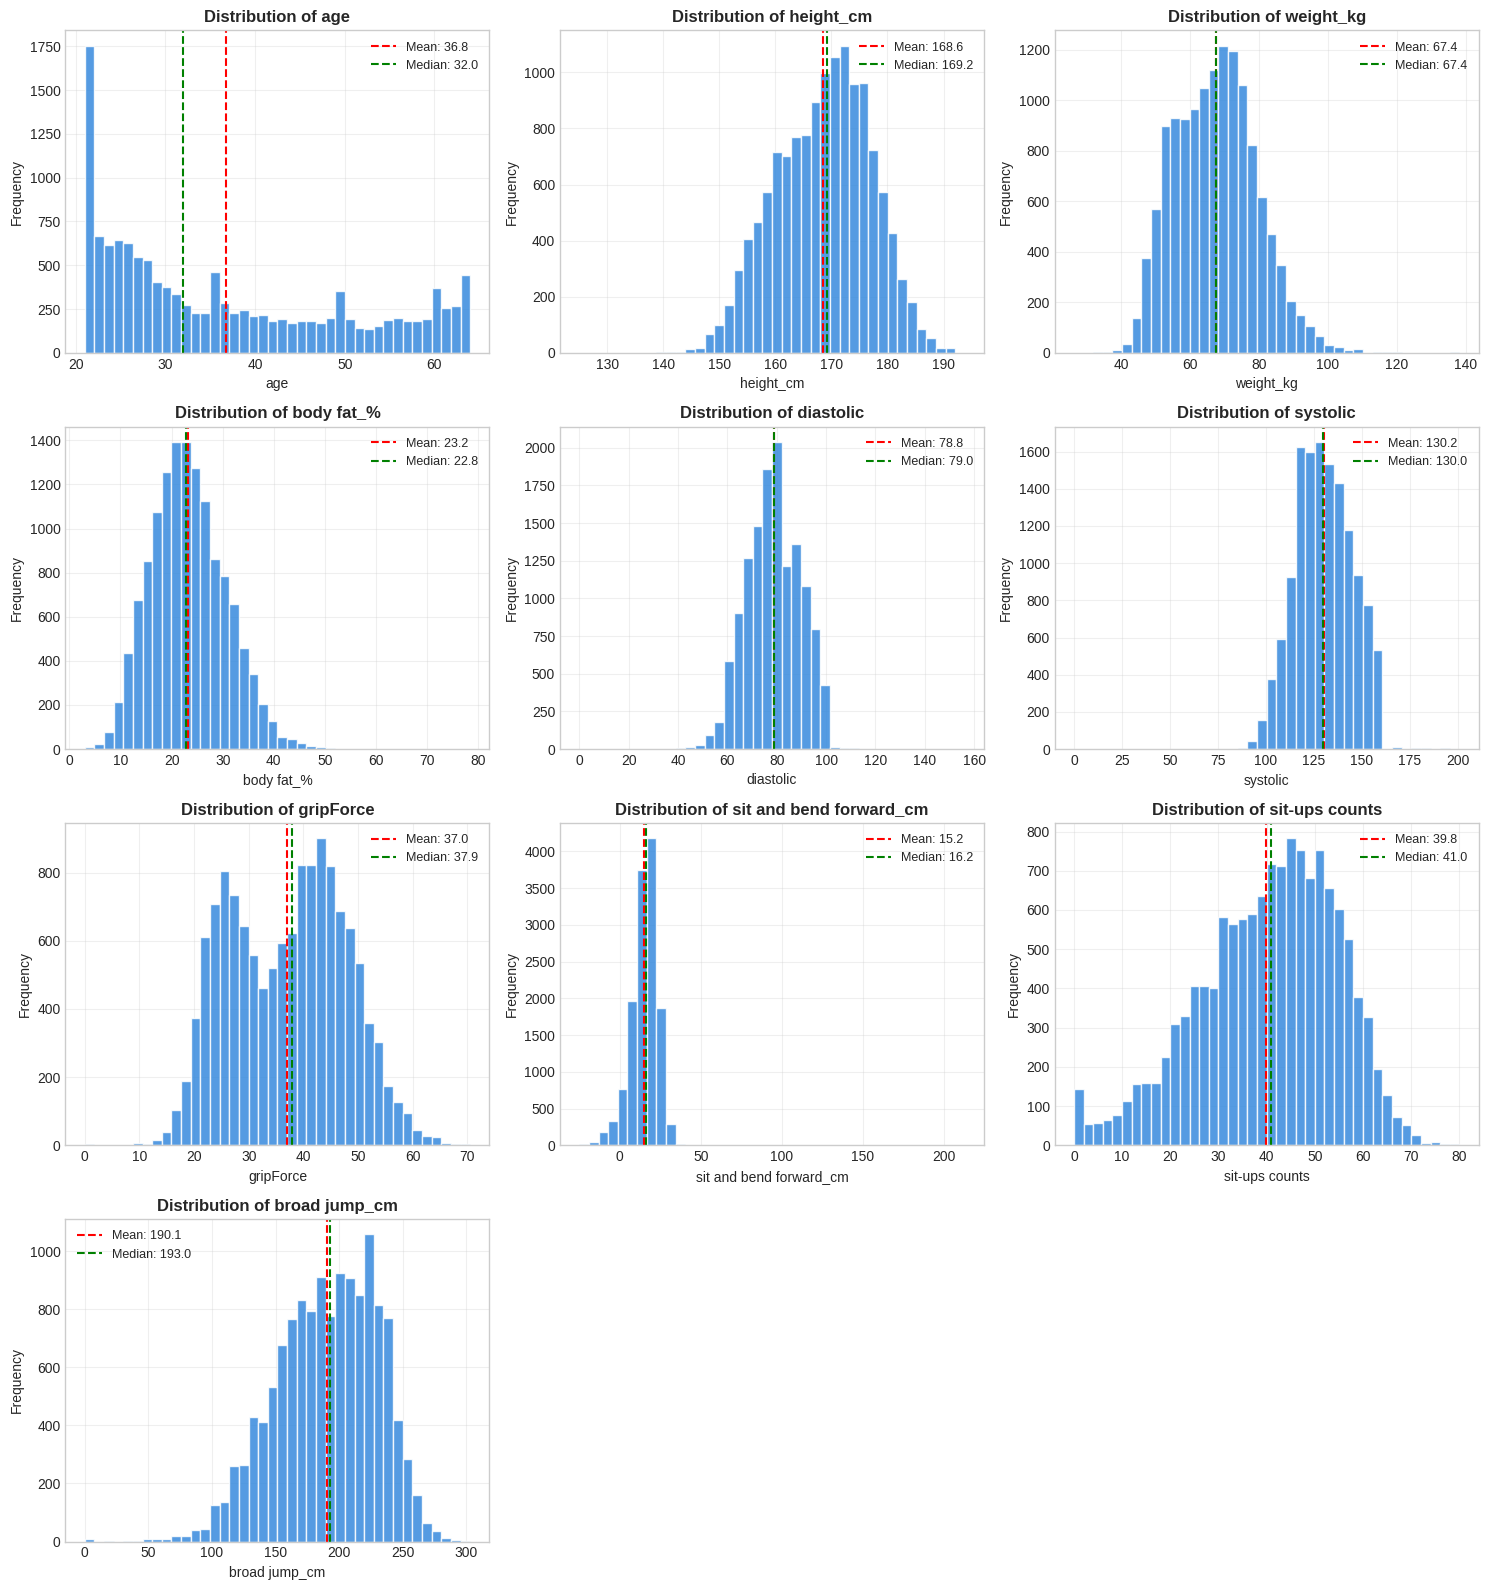

In [242]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
print(f"numeric_cols ({len(numeric_cols)}): {numeric_cols}")

import math

n_cols = 3
n_rows = math.ceil(len(numeric_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(n_cols * 5, n_rows * 4))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    ax = axes[idx]
    data = df[col].dropna()

    #histogram
    ax.hist(data, bins=40, color='#378ADD',
            edgecolor='white', alpha=0.85)

    #(mean)
    ax.axvline(data.mean(),   color='red',   linestyle='--',
               linewidth=1.5, label=f'Mean: {data.mean():.1f}')

    #(median)
    ax.axvline(data.median(), color='green', linestyle='--',
               linewidth=1.5, label=f'Median: {data.median():.1f}')


    ax.set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)


for idx in range(len(numeric_cols), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

In [243]:
'''Distribution Observations:
Normal Distributions: Height, weight, grip force, and broad jump approximate normal distributions
Skewed Distributions: Age and body fat percentage show right skew (younger participants, higher fat percentages)
Outliers: Sit and bend forward shows extreme outlier at 213 cm; sit-ups and broad jump have lower bound outliers'''

'Distribution Observations:\nNormal Distributions: Height, weight, grip force, and broad jump approximate normal distributions\nSkewed Distributions: Age and body fat percentage show right skew (younger participants, higher fat percentages)\nOutliers: Sit and bend forward shows extreme outlier at 213 cm; sit-ups and broad jump have lower bound outliers'

In [244]:
#2.8 Outlier Detection

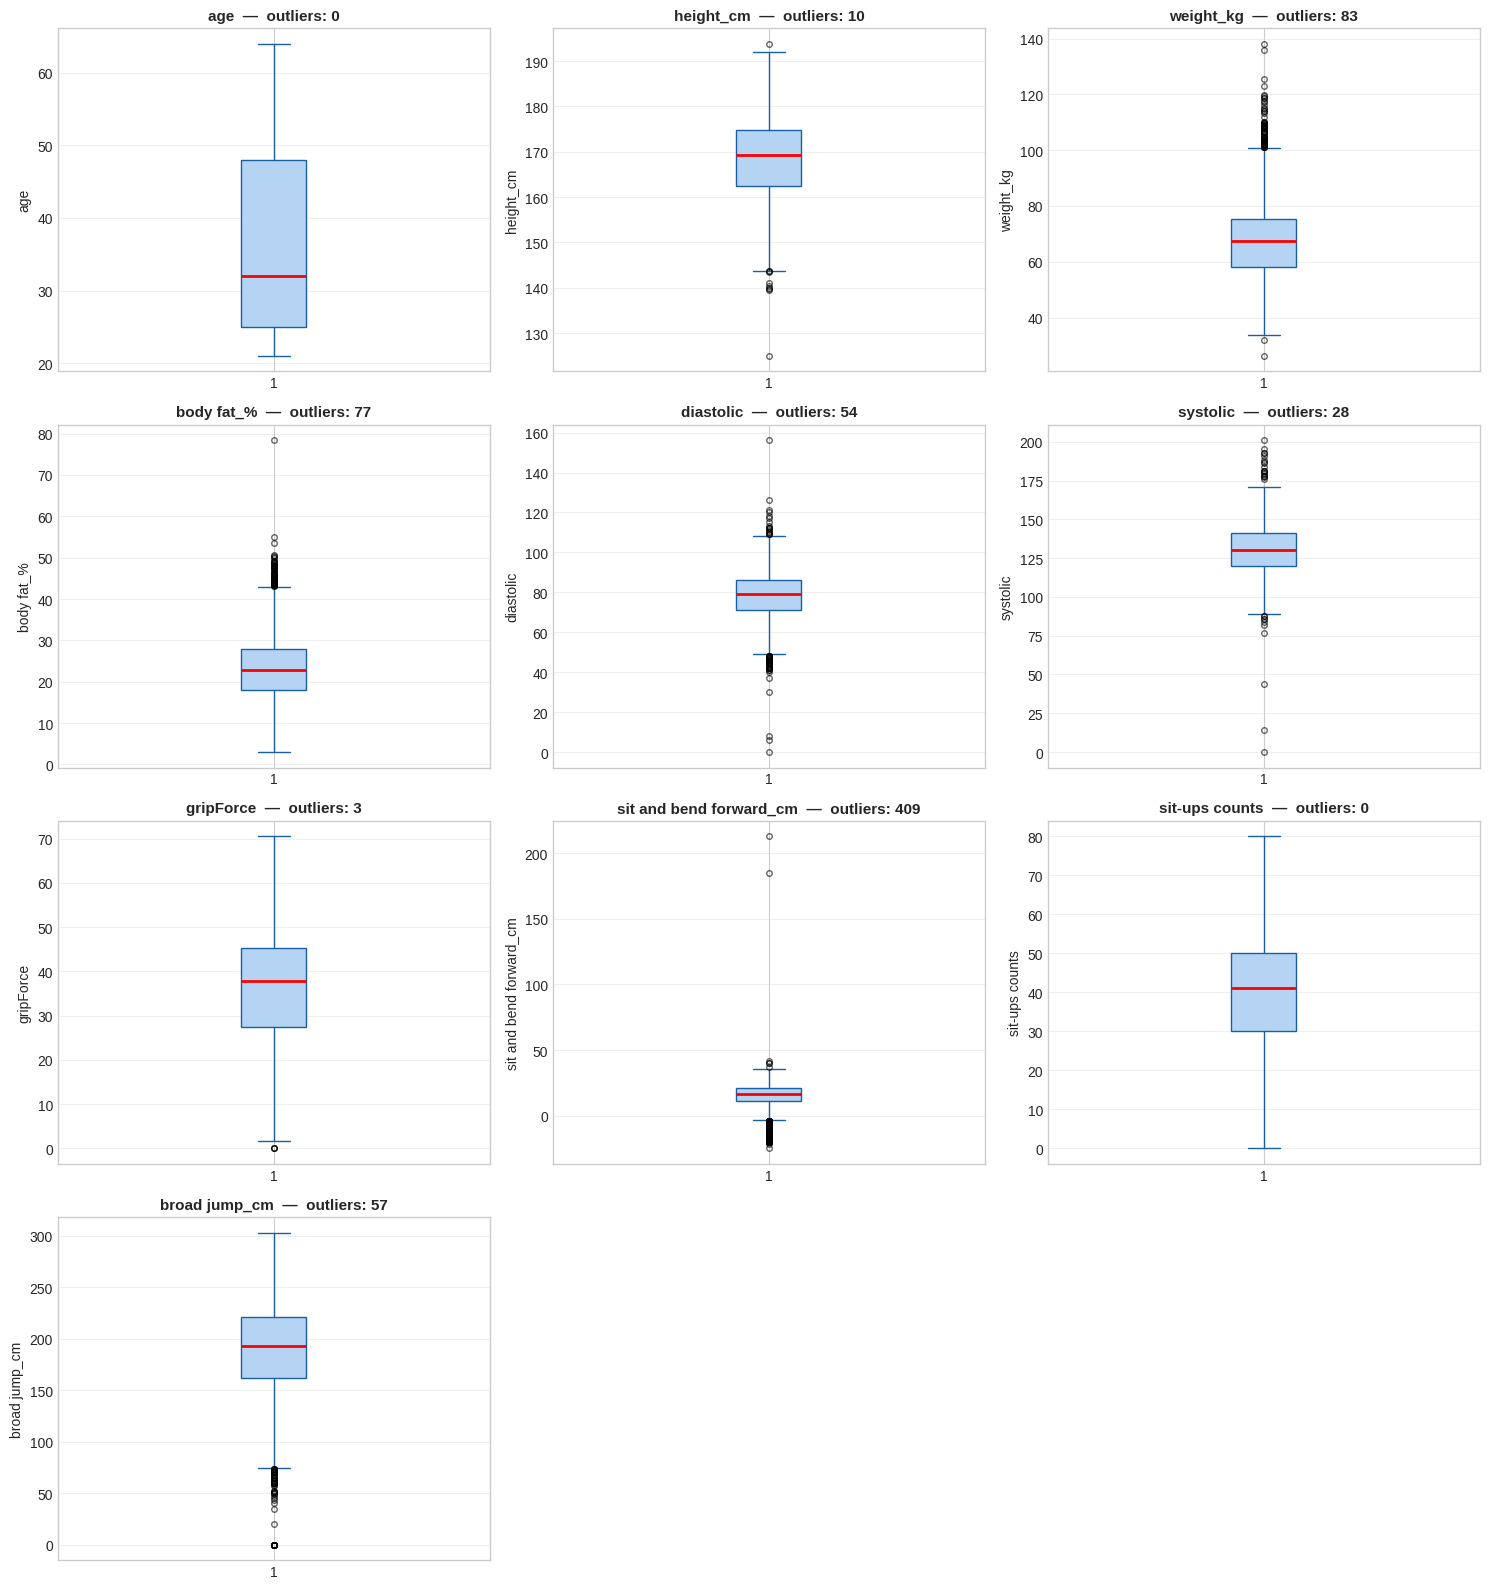

In [245]:
import math

numeric_cols = df.select_dtypes(include='number').columns.tolist()

n_cols = 3
n_rows = math.ceil(len(numeric_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(n_cols * 5, n_rows * 4))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    ax = axes[idx]

    #boxplot
    ax.boxplot(df[col].dropna(),
               patch_artist=True,
               boxprops=dict(facecolor='#B5D4F4', color='#185FA5'),
               medianprops=dict(color='red', linewidth=2),
               whiskerprops=dict(color='#185FA5'),
               capprops=dict(color='#185FA5'),
               flierprops=dict(marker='o', color='#E24B4A',  #outliers
                                markersize=4, alpha=0.6))

    #outliers
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) |
                   (df[col] > Q3 + 1.5 * IQR)][col]


    ax.set_title(f'{col}  —  outliers: {len(outliers)}',
                 fontsize=11, fontweight='bold')
    ax.set_ylabel(col)
    ax.grid(True, alpha=0.3, axis='y')

# subplots
for idx in range(len(numeric_cols), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

In [246]:
print("Outlier Report (IQR method):\n")
for col in numeric_cols:
    Q1       = df[col].quantile(0.25)
    Q3       = df[col].quantile(0.75)
    IQR      = Q3 - Q1
    lower    = Q1 - 1.5 * IQR
    upper    = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)][col]

    print(f"{col}:")
    print(f"  Normal range: [{lower:.2f}  →  {upper:.2f}]")
    print(f"num of outliers: {len(outliers)}")
    print(f"ratio : {len(outliers)/len(df)*100:.2f}%\n")

Outlier Report (IQR method):

age:
  Normal range: [-9.50  →  82.50]
num of outliers: 0
ratio : 0.00%

height_cm:
  Normal range: [143.80  →  193.40]
num of outliers: 10
ratio : 0.07%

weight_kg:
  Normal range: [32.55  →  100.95]
num of outliers: 83
ratio : 0.62%

body fat_%:
  Normal range: [3.00  →  43.00]
num of outliers: 77
ratio : 0.57%

diastolic:
  Normal range: [48.50  →  108.50]
num of outliers: 54
ratio : 0.40%

systolic:
  Normal range: [88.50  →  172.50]
num of outliers: 28
ratio : 0.21%

gripForce:
  Normal range: [0.95  →  71.75]
num of outliers: 3
ratio : 0.02%

sit and bend forward_cm:
  Normal range: [-3.80  →  35.40]
num of outliers: 409
ratio : 3.05%

sit-ups counts:
  Normal range: [0.00  →  80.00]
num of outliers: 0
ratio : 0.00%

broad jump_cm:
  Normal range: [73.50  →  309.50]
num of outliers: 57
ratio : 0.43%



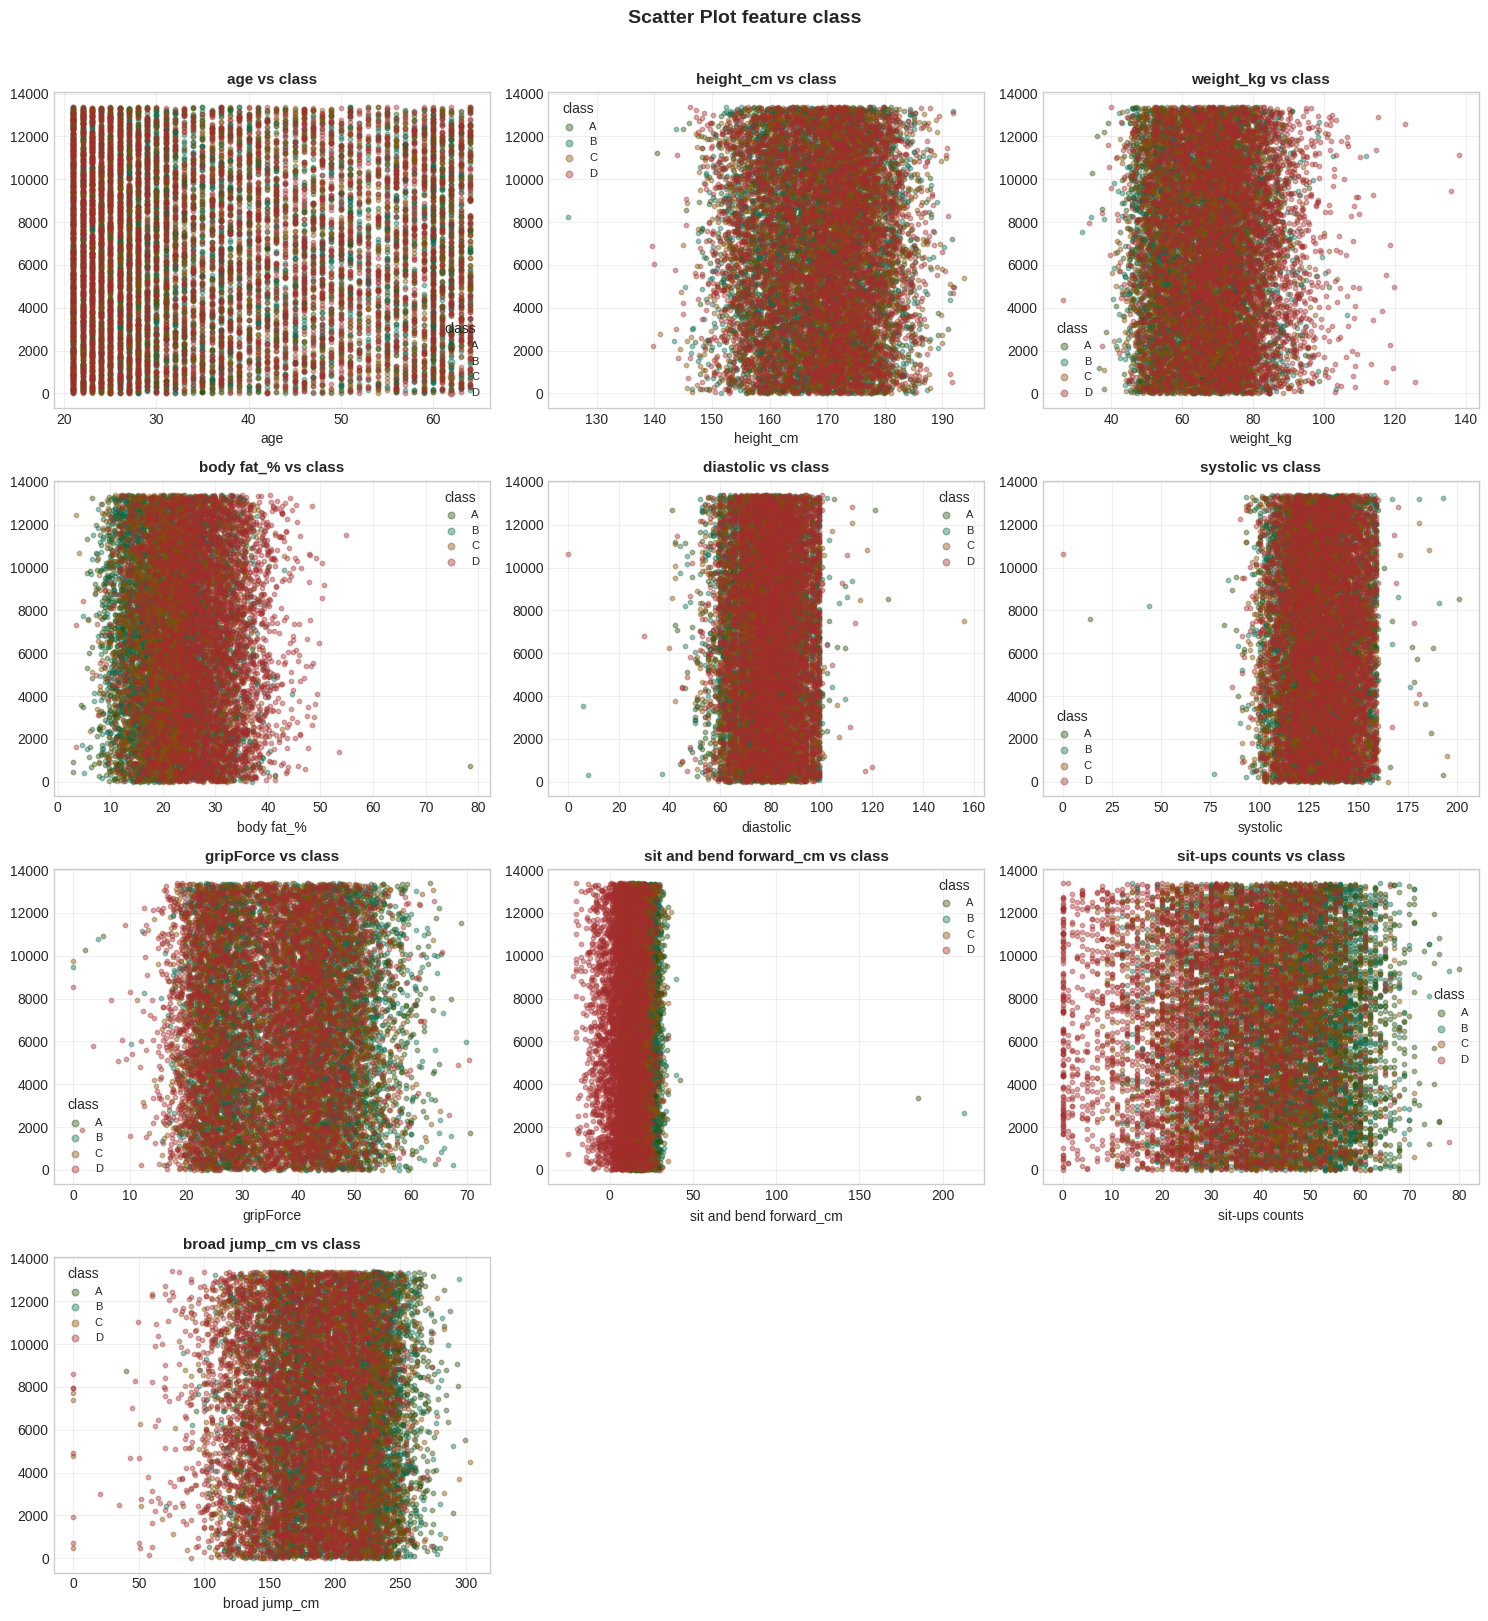

In [247]:
import math

numeric_cols = df.select_dtypes(include='number').columns.tolist()

#class
colors = {'A': '#27500A', 'B': '#0F6E56',
           'C': '#854F0B', 'D': '#A32D2D'}

n_cols = 3
n_rows = math.ceil(len(numeric_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(n_cols * 5, n_rows * 4))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    ax = axes[idx]

    for cls, color in colors.items():
        subset = df[df['class'] == cls]
        ax.scatter(subset[col],
                   subset.index,
                   c=color, label=cls,
                   alpha=0.4, s=10)

    ax.set_title(f'{col} vs class', fontsize=11, fontweight='bold')
    ax.set_xlabel(col)
    ax.legend(title='class', fontsize=8, markerscale=1.5)
    ax.grid(True, alpha=0.3)

for idx in range(len(numeric_cols), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Scatter Plot feature class',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

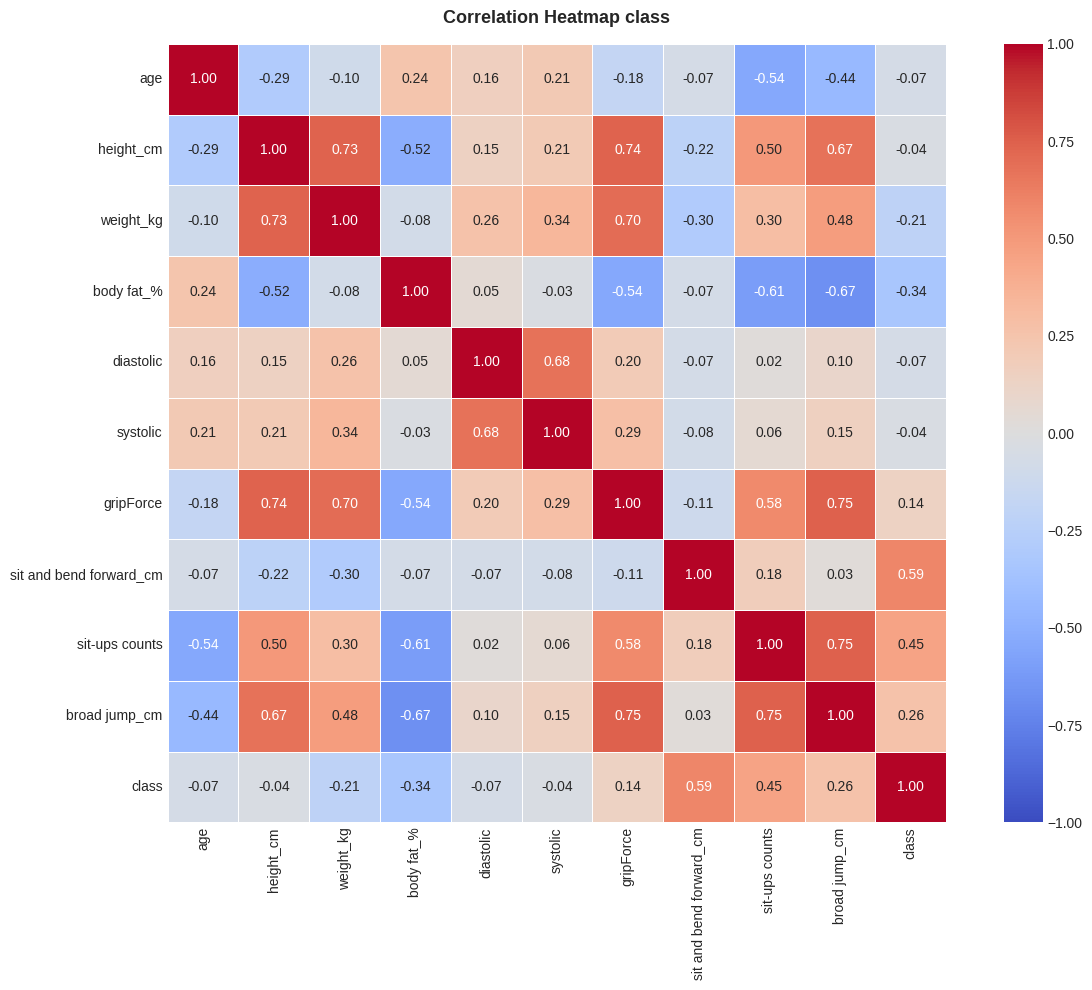

In [248]:
df_corr = df.copy()
df_corr['class'] = df_corr['class'].map(
    {'A': 4, 'B': 3, 'C': 2, 'D': 1}
)

# 2. class
numeric_cols = df_corr.select_dtypes(include='number').columns.tolist()
corr_matrix  = df_corr[numeric_cols].corr()

# 3.heatmap
fig, ax = plt.subplots(figsize=(13, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax
)

ax.set_title('Correlation Heatmap class',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [249]:
class_corr = (corr_matrix['class']
               .drop('class')
               .abs()
               .sort_values(ascending=False))

print("class correlation ")
for col, val in class_corr.items():
    bar = '█' * int(val * 20)
    print(f"  {col:28} {val:.3f}  {bar}")

class correlation 
  sit and bend forward_cm      0.588  ███████████
  sit-ups counts               0.453  █████████
  body fat_%                   0.342  ██████
  broad jump_cm                0.262  █████
  weight_kg                    0.214  ████
  gripForce                    0.136  ██
  diastolic                    0.067  █
  age                          0.066  █
  height_cm                    0.038  
  systolic                     0.035  


In [250]:
cols_to_clean = [
    'height_cm', 'weight_kg', 'body fat_%',
    'diastolic', 'systolic', 'gripForce', 'broad jump_cm'
]

df_clean = df.copy()
before   = len(df_clean)

for col in cols_to_clean:
    Q1  = df_clean[col].quantile(0.25)
    Q3  = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    removed = df_clean[(df_clean[col] < lower) |
                        (df_clean[col] > upper)]
    print(f"{col}: Delete {len(removed)} for [{lower:.1f} → {upper:.1f}]")

    df_clean = df_clean[
        (df_clean[col] >= lower) &
        (df_clean[col] <= upper)
    ]

after = len(df_clean)
print(f"\n Before {before} column |  After: {after} column  | Deleted : {before - after} ({(before-after)/before*100:.2f}%)")

height_cm: Delete 10 for [143.8 → 193.4]
weight_kg: Delete 83 for [32.6 → 100.9]
body fat_%: Delete 82 for [3.2 → 42.8]
diastolic: Delete 54 for [48.5 → 108.5]
systolic: Delete 18 for [88.5 → 172.5]
gripForce: Delete 3 for [1.4 → 71.3]
broad jump_cm: Delete 41 for [74.5 → 310.5]

 Before 13392 column |  After: 13101 column  | Deleted : 291 (2.17%)


In [251]:
cap_col = 'sit and bend forward_cm'
cap_min = -20
cap_max =  40

before_cap = df_clean[cap_col].describe()

df_clean[cap_col] = df_clean[cap_col].clip(lower=cap_min, upper=cap_max)

print(f"Capping '{cap_col}' between {cap_min} and {cap_max}")
print(f"Min capping: {df_clean[cap_col].min()}")
print(f"Max capping: {df_clean[cap_col].max()}")


Capping 'sit and bend forward_cm' between -20 and 40
Min capping: -20.0
Max capping: 40.0


=== Shape ===
Rows: 13101  |  Cols: 12

=== Outliers ===
  age: 0 outliers
  height_cm: 1 outliers
  weight_kg: 4 outliers
  body fat_%: 5 outliers
  diastolic: 0 outliers
  systolic: 0 outliers
  gripForce: 0 outliers
  sit and bend forward_cm: 386 outliers
  sit-ups counts: 83 outliers
  broad jump_cm: 0 outliers


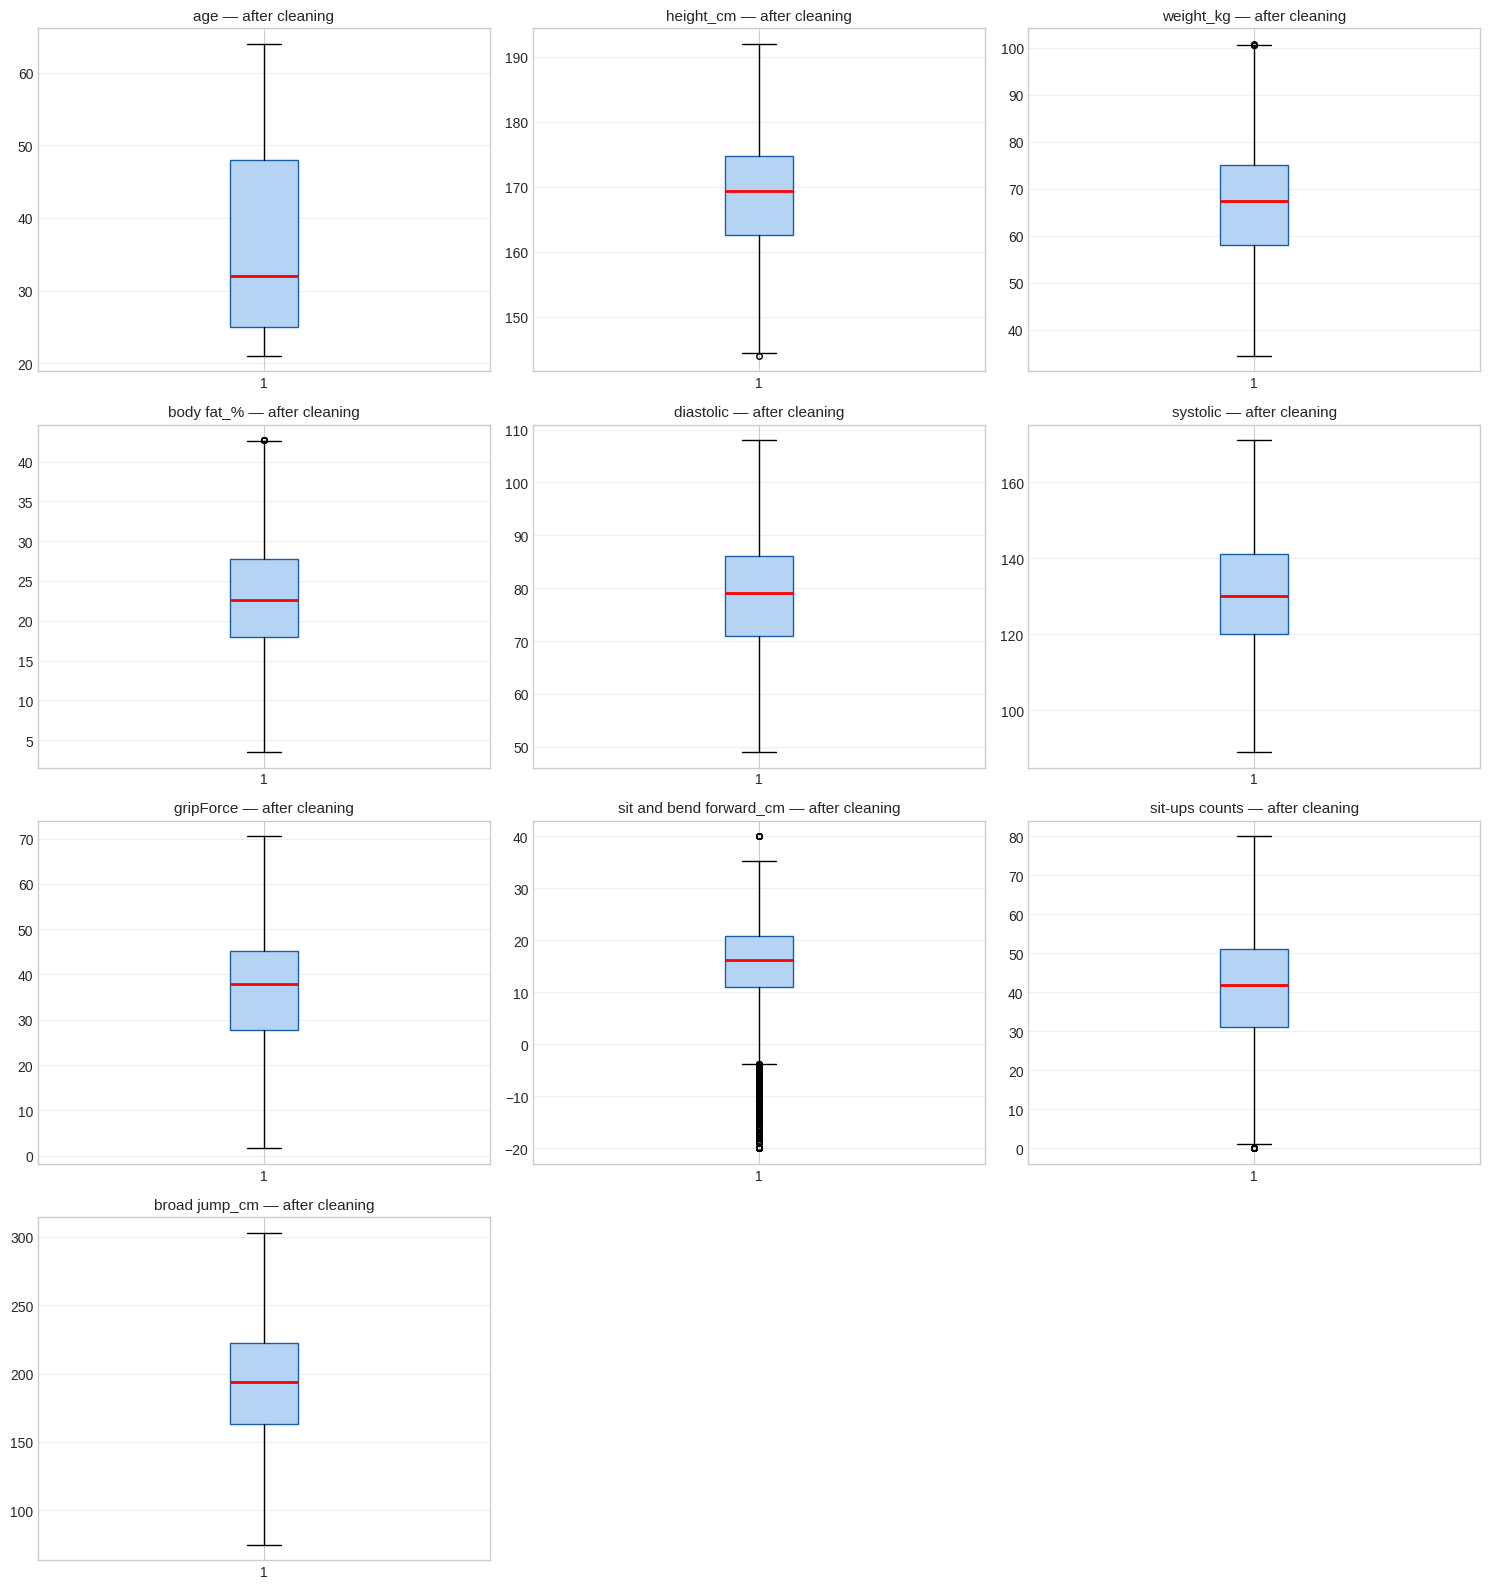

In [252]:
print("=== Shape ===")
print(f"Rows: {df_clean.shape[0]}  |  Cols: {df_clean.shape[1]}\n")

print("=== Outliers ===")
for col in df_clean.select_dtypes(include='number').columns:
    Q1      = df_clean[col].quantile(0.25)
    Q3      = df_clean[col].quantile(0.75)
    IQR     = Q3 - Q1
    n_out   = len(df_clean[
                   (df_clean[col] < Q1 - 1.5*IQR) |
                   (df_clean[col] > Q3 + 1.5*IQR)])
    print(f"  {col}: {n_out} outliers")

#boxplots
import math
num_cols = df_clean.select_dtypes(include='number').columns
n_cols   = 3
n_rows   = math.ceil(len(num_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*4))
axes = axes.flatten()
for idx, col in enumerate(num_cols):
    axes[idx].boxplot(df_clean[col].dropna(),
                       patch_artist=True,
                       boxprops=dict(facecolor='#B5D4F4', color='#185FA5'),
                       medianprops=dict(color='red', linewidth=2),
                       flierprops=dict(marker='o', color='#E24B4A', markersize=4))
    axes[idx].set_title(f'{col} — after cleaning', fontsize=11)
    axes[idx].grid(True, alpha=0.3, axis='y')
for idx in range(len(num_cols), len(axes)):
    axes[idx].set_visible(False)
plt.tight_layout()
plt.show()

In [253]:
from sklearn.preprocessing import LabelEncoder

# gender: M=1, F=0
le = LabelEncoder()
df_clean['gender'] = le.fit_transform(df_clean['gender'])

print("gender encoding:", dict(zip(le.classes_, le.transform(le.classes_))))

# class: A=4, B=3, C=2, D=1
df_clean['class'] = df_clean['class'].map(
    {'A': 4, 'B': 3, 'C': 2, 'D': 1}
)

print("class encoding: A=4, B=3, C=2, D=1")
print("\n data after encoding:")
print(df_clean[['gender', 'class']].head(5))

gender encoding: {'F': np.int64(0), 'M': np.int64(1)}
class encoding: A=4, B=3, C=2, D=1

 data after encoding:
   gender  class
0       1      2
1       1      4
2       1      2
3       1      3
4       1      3


In [254]:
#features and target
X = df_clean.drop(columns=['class'])
y = df_clean['class']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\n classes:")
print(y.value_counts().sort_index())

X shape: (13101, 11)
y shape: (13101,)

 classes:
class
1    3141
2    3323
3    3317
4    3320
Name: count, dtype: int64


In [255]:
df["BMI"] = df["weight_kg"] / ((df["height_cm"]/100)**2)

In [256]:
from sklearn.preprocessing import LabelEncoder

# Use df_clean which has already been processed and has numerical 'class' and 'gender' (if not already done)
X = df_clean.drop("class", axis=1)   # features
y = df_clean["class"]                # target

# The 'gender' column in df_clean is already encoded in cell 'cra19nQXGI-3'
# The 'class' column in df_clean is already encoded in cell 'cra19nQXGI-3'

print("X shape (from df_clean):", X.shape)
print("y shape (from df_clean):", y.shape)
print("Target variable 'y' from df_clean (first 5 values):\n", y.head())

X shape (from df_clean): (13101, 11)
y shape (from df_clean): (13101,)
Target variable 'y' from df_clean (first 5 values):
 0    2
1    4
2    2
3    3
4    3
Name: class, dtype: int64


In [257]:
# This cell is no longer needed as 'y' is derived directly from df_clean
# where 'class' is already numerically encoded in cell 'cra19nQXGI-3'.

Split 80-20 -> Simple Acc: 0.6074, CV Mean Acc: 0.5925
Split 70-30 -> Simple Acc: 0.5920, CV Mean Acc: 0.5954
Split 50-50 -> Simple Acc: 0.5909, CV Mean Acc: 0.5863


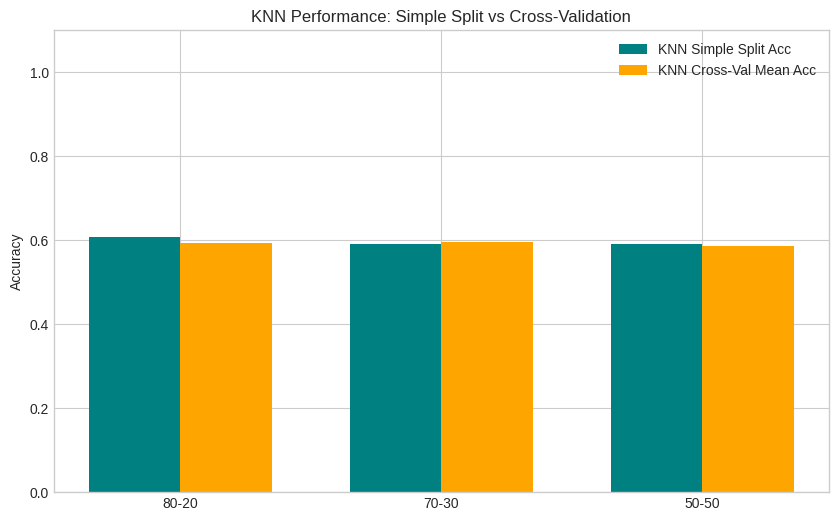

In [258]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler # ضروري جداً لـ KNN
from sklearn.metrics import accuracy_score

# 1. عمل Scaling للبيانات (خطوة حاسمة لـ KNN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# تعريف النسب والموديل (سنستخدم k=5 كقيمة افتراضية)
test_sizes = [0.2, 0.3, 0.5]
labels = ['80-20', '70-30', '50-50']
simple_accuracies = []
cv_mean_accuracies = []

# تعريف موديل KNN
knn_model = KNeighborsClassifier(n_neighbors=5)

for size in test_sizes:
    # التقسيم باستخدام البيانات التي تم عمل Scaling لها
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=size, random_state=42
    )

    # حساب الدقة العادية
    knn_model.fit(X_train, y_train)
    simple_acc = accuracy_score(y_test, knn_model.predict(X_test))
    simple_accuracies.append(simple_acc)

    # إضافة Cross-Validation
    cv_scores = cross_val_score(knn_model, X_train, y_train, cv=5)
    cv_mean_accuracies.append(cv_scores.mean())

    print(f"Split {100-size*100:.0f}-{size*100:.0f} -> Simple Acc: {simple_acc:.4f}, CV Mean Acc: {cv_scores.mean():.4f}")

# رسم المقارنة
x = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, simple_accuracies, width, label='KNN Simple Split Acc', color='teal')
rects2 = ax.bar(x + width/2, cv_mean_accuracies, width, label='KNN Cross-Val Mean Acc', color='orange')

ax.set_ylabel('Accuracy')
ax.set_title('KNN Performance: Simple Split vs Cross-Validation')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.set_ylim([0, 1.1])
plt.show()

In [259]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

KNeighborsClassifier()

In [260]:
y_pred = knn.predict(X_test)

80-20 Split: Best K = 15 with Accuracy = 0.6330
70-30 Split: Best K = 12 with Accuracy = 0.6202
50-50 Split: Best K = 17 with Accuracy = 0.6159


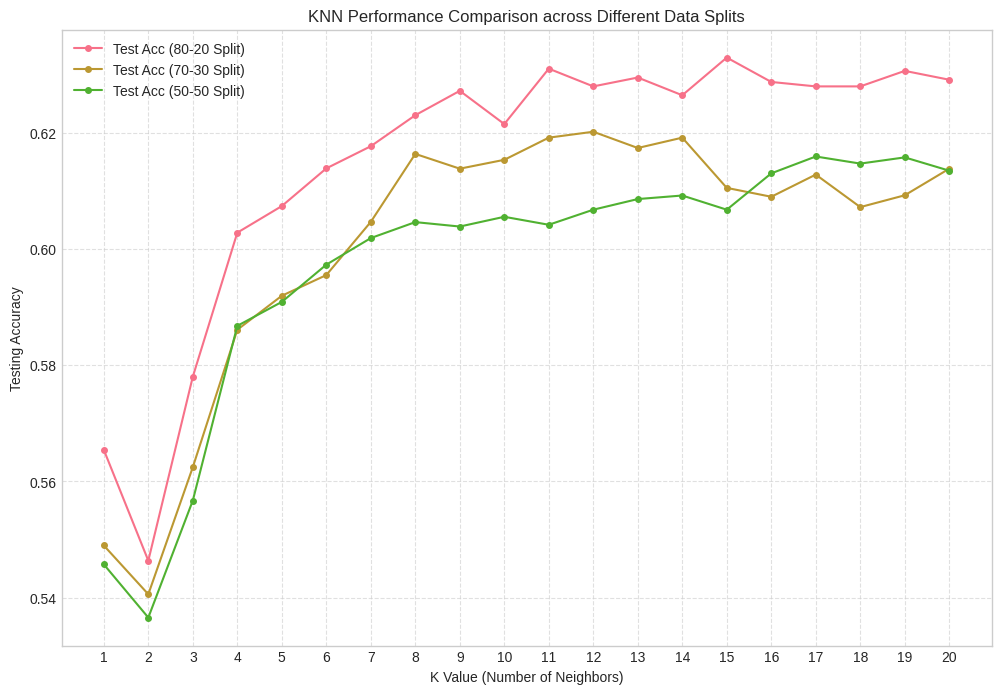

In [261]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

# 1. تجهيز البيانات (Scaling ضروري لـ KNN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. تعريف الإعدادات
test_sizes = [0.2, 0.3, 0.5]
labels = ['80-20 Split', '70-30 Split', '50-50 Split']
k_values = range(1, 21)

plt.figure(figsize=(12, 8))

# 3. الحلقة التكرارية للتقسيمات المختلفة
for size, label in zip(test_sizes, labels):
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=size, random_state=42
    )

    current_test_acc = []

    # 4. تجربة قيم K لكل تقسيمة
    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train, y_train)

        # هنركز هنا على Test Accuracy لأنها الأهم للتقييم
        y_pred = knn.predict(X_test)
        current_test_acc.append(accuracy_score(y_test, y_pred))

    # 5. رسم الخط الخاص بكل تقسيمة
    plt.plot(k_values, current_test_acc, label=f"Test Acc ({label})", marker='o', markersize=4)

    # طباعة أفضل قيمة K لكل تقسيمة
    best_k = k_values[np.argmax(current_test_acc)]
    max_acc = max(current_test_acc)
    print(f"{label}: Best K = {best_k} with Accuracy = {max_acc:.4f}")

# 6. تنسيق الرسم البياني
plt.xlabel("K Value (Number of Neighbors)")
plt.ylabel("Testing Accuracy")
plt.title("KNN Performance Comparison across Different Data Splits")
plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

In [262]:
#decision tree

In [263]:
X = df.drop("class", axis=1)
y = df["class"]

# Encode the 'gender' column in X
from sklearn.preprocessing import LabelEncoder
le_gender = LabelEncoder()
X['gender'] = le_gender.fit_transform(X['gender'])

print("X head after gender encoding:")
print(X.head())

X head after gender encoding:
   age  gender  height_cm  weight_kg  body fat_%  diastolic  systolic  \
0   27       1      172.3      75.24        21.3       80.0     130.0   
1   25       1      165.0      55.80        15.7       77.0     126.0   
2   31       1      179.6      78.00        20.1       92.0     152.0   
3   32       1      174.5      71.10        18.4       76.0     147.0   
4   28       1      173.8      67.70        17.1       70.0     127.0   

   gripForce  sit and bend forward_cm  sit-ups counts  broad jump_cm  \
0       54.9                     18.4            60.0          217.0   
1       36.4                     16.3            53.0          229.0   
2       44.8                     12.0            49.0          181.0   
3       41.4                     15.2            53.0          219.0   
4       43.5                     27.1            45.0          217.0   

         BMI  
0  25.344179  
1  20.495868  
2  24.181428  
3  23.349562  
4  22.412439  


In [264]:
train_acc = []
test_acc = []
depths = range(1, 21)

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)

    train_pred = dt.predict(X_train)
    test_pred = dt.predict(X_test)

    from sklearn.metrics import accuracy_score

    train_acc.append(accuracy_score(y_train, train_pred))
    test_acc.append(accuracy_score(y_test, test_pred))

Accuracy for 80-20 split: 0.7372
Accuracy for 70-30 split: 0.7325
Accuracy for 50-50 split: 0.7236


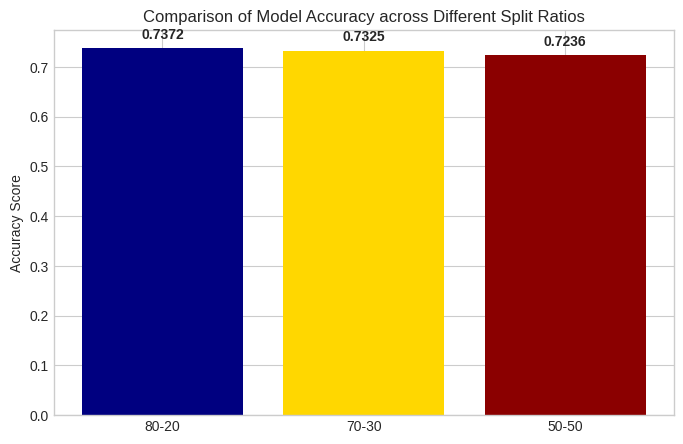

In [265]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# تعريف النسب المطلوبة
test_sizes = [0.2, 0.3, 0.5]
labels = ['80-20', '70-30', '50-50']
accuracies = []

# نموذج تجريبي (استبدله بموديلك الخاص إذا أردت)
model = RandomForestClassifier(random_state=42)

for size in test_sizes:
    # التقسيم بناءً على النسبة الحالية
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=size, random_state=42
    )

    # التدريب
    model.fit(X_train, y_train)

    # التنبؤ وحساب الدقة
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    print(f"Accuracy for {100-size*100:.0f}-{size*100:.0f} split: {acc:.4f}")

# رسم المقارنة بيانيًا
plt.figure(figsize=(8, 5))
plt.bar(labels, accuracies, color=['navy', 'gold', 'darkred'])
plt.ylabel('Accuracy Score')
plt.title('Comparison of Model Accuracy across Different Split Ratios')
plt.ylim() # لضبط مقياس الرسم
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')
plt.show()

Split 80-20 -> Simple Acc: 0.7372, CV Mean Acc: 0.7244
Split 70-30 -> Simple Acc: 0.7325, CV Mean Acc: 0.7191
Split 50-50 -> Simple Acc: 0.7236, CV Mean Acc: 0.7046


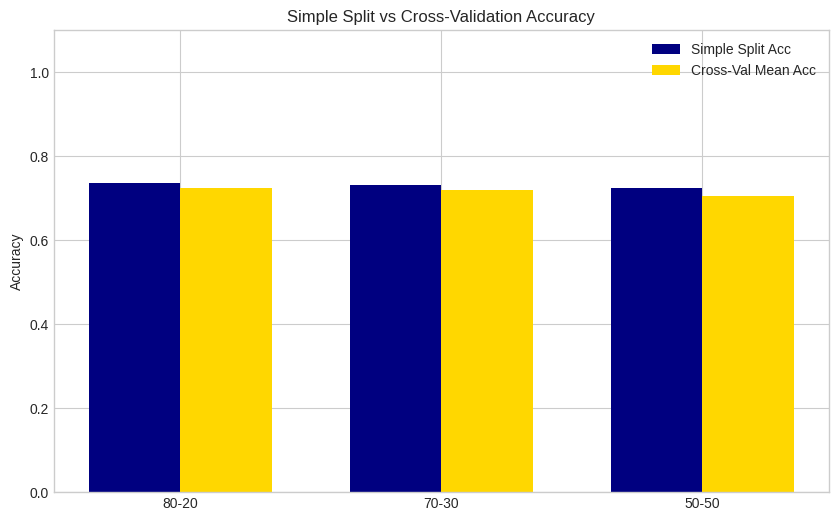

In [266]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# تعريف النسب والموديل
test_sizes = [0.2, 0.3, 0.5]
labels = ['80-20', '70-30', '50-50']
simple_accuracies = []
cv_mean_accuracies = []

model = RandomForestClassifier(random_state=42)

for size in test_sizes:
    # 1. التقسيم العادي
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=size, random_state=42
    )

    # حساب الدقة العادية (Hold-out method)
    model.fit(X_train, y_train)
    simple_acc = accuracy_score(y_test, model.predict(X_test))
    simple_accuracies.append(simple_acc)

    # 2. إضافة Cross-Validation على بيانات التدريب فقط
    # سنقوم بتقسيم بيانات التدريب لـ 5 أجزاء ونلف بينهم
    cv_scores = cross_val_score(model, X_train, y_train, cv=8)
    cv_mean_accuracies.append(cv_scores.mean())

    print(f"Split {100-size*100:.0f}-{size*100:.0f} -> Simple Acc: {simple_acc:.4f}, CV Mean Acc: {cv_scores.mean():.4f}")

# رسم المقارنة
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, simple_accuracies, width, label='Simple Split Acc', color='navy')
rects2 = ax.bar(x + width/2, cv_mean_accuracies, width, label='Cross-Val Mean Acc', color='gold')

ax.set_ylabel('Accuracy')
ax.set_title('Simple Split vs Cross-Validation Accuracy')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.set_ylim([0, 1.1])

plt.show()

In [267]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,
    mean_squared_error, r2_score
)
import warnings
warnings.filterwarnings('ignore')

In [268]:
def load_and_preprocess_data(df):
    """
    Load and preprocess the dataset.

    Parameters:
    -----------
    df : DataFrame
        Input dataframe

    Returns:
    --------
    df : DataFrame
        Preprocessed dataframe
    """
    print("--- Loading and Preprocessing Data ---")

    # Read the dataset and drop any missing values
    df = pd.read_csv('/content/data.csv').dropna()

    # Map numeric class codes (1, 2, 3, 4) to categorical letters (A, B, C, D)
    class_mapping = {1: 'A', 2: 'B', 3: 'C', 4: 'D'}
    if pd.api.types.is_numeric_dtype(df['class']):
        df['class'] = df['class'].map(class_mapping)

    # Encode 'gender' column from categorical ('M', 'F') to numerical (0, 1)
    le = LabelEncoder()
    df['gender'] = le.fit_transform(df['gender'])

    print(f"Data shape after preprocessing: {df.shape}")
    return df

In [269]:
# ============================================================================
# 2. CLASSIFICATION TASK
# ============================================================================

def classification_task(df, test_size):
    """
    Perform classification using SVM to predict class codes (A, B, C, D).

    Parameters:
    -----------
    df : DataFrame
        Input dataframe
    test_size : float
        Proportion of data to use for testing (0.20, 0.30, or 0.50)
    """
    print(f"\n{'='*54}")
    print(f"--- Classification Task (Test Size: {int(test_size*100)}%) ---")
    print(f"{'='*54}")

    # Separate features (X) from the target variable (y)
    X = df.drop('class', axis=1)
    y = df['class']

    # Split the data into training and testing sets FIRST to avoid Data Leakage
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    # Standardize features by removing the mean and scaling to unit variance
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)  # Only transform the test set

    # Initialize and train the Support Vector Machine (SVM) classifier
    model = SVC(kernel='rbf', C=1.0, random_state=42)
    model.fit(X_train_scaled, y_train)

    # Make predictions on both train and test sets
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    # Evaluate model performance using Accuracy
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    print(f"  Training Accuracy: {train_acc:.4f}")
    print(f"  Testing Accuracy:  {test_acc:.4f}")
    print(f"  Accuracy Gap:      {abs(train_acc - test_acc):.4f}")

    # Generate and plot the Confusion Matrix
    cm = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=model.classes_, yticklabels=model.classes_
    )
    plt.title(f'Confusion Matrix - SVM (Test Size: {int(test_size*100)}%)')
    plt.xlabel('Predicted Class')
    plt.ylabel('Actual Class')
    plt.tight_layout()
    plt.show()

In [270]:
# ============================================================================
# 3. REGRESSION TASK
# ============================================================================

def regression_task(df, test_size):
    """
    Perform regression to predict broad_jump values.

    Parameters:
    -----------
    df : DataFrame
        Input dataframe
    test_size : float
        Proportion of data to use for testing (0.20, 0.30, or 0.50)
    """
    print(f"\n{'='*54}")
    print(f"--- Regression Task: Predict broad_jump (Test Size: {int(test_size*100)}%) ---")
    print(f"{'='*54}")

    # Create a copy of the dataframe to keep the original safe
    df_reg = df.copy()

    # Encode the categorical 'class' back to numbers for regression
    le = LabelEncoder()
    df_reg['class'] = le.fit_transform(df_reg['class'])

    # Define features (X) and target (y)
    X = df_reg.drop('broad jump_cm', axis=1)
    y = df_reg['broad jump_cm']

    # Split the dataset
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    # Feature scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Initialize regression models: Linear Regression
    models = {
        "Linear Regression": LinearRegression(),
    }

    for name, model in models.items():
        print(f"\n🔹 Model: {name}")

        # Train the selected model
        model.fit(X_train_scaled, y_train)

        # Make predictions
        y_train_pred = model.predict(X_train_scaled)
        y_test_pred = model.predict(X_test_scaled)

        # Calculate MSE for additional insight
        train_mse = mean_squared_error(y_train, y_train_pred)
        test_mse = mean_squared_error(y_test, y_test_pred)

        # Evaluate model performance using R-squared (R2) score
        train_r2 = r2_score(y_train, y_train_pred)
        test_r2 = r2_score(y_test, y_test_pred)

        print(f"  Training R² Score: {train_r2:.4f}")
        print(f"  Testing R² Score:  {test_r2:.4f}")
        print(f"  R² Gap:            {abs(train_r2 - test_r2):.4f}")
        print(f"  Training MSE:      {train_mse:.4f}")
        print(f"  Testing MSE:       {test_mse:.4f}")

        # Plot Actual vs. Predicted values
        plt.figure(figsize=(6, 5))
        plt.plot(
            [y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()],
            'k--', lw=2, label='Perfect Prediction'
        )
        plt.scatter(
            y_test, y_test_pred, alpha=0.5,
            color='darkorange' if 'Linear Regression' in name else 'steelblue'
        )
        plt.title(f'{name} - Actual vs Predicted ({int(test_size*100)}%)')
        plt.xlabel('Actual Broad Jump (cm)')
        plt.ylabel('Predicted Broad Jump (cm)')
        plt.legend()
        plt.tight_layout()
        plt.show()

In [271]:
# ============================================================================
# 4. K-FOLD CROSS VALIDATION
# ============================================================================

def kfold_cross_validation(df, k=5):
    """
    Perform K-Fold Cross Validation for both classification and regression tasks.

    Parameters:
    -----------
    df : DataFrame
        Input dataframe
    k : int
        Number of folds for cross-validation
    """
    print(f"\n{'='*54}")
    print(f"--- K-Fold Cross Validation (K={k}) ---")
    print(f"{'='*54}")

    # --- Classification K-Fold ---
    print("\n🔹 Classification Task (SVM):")
    X_c = df.drop('class', axis=1)
    y_c = df['class']
    scaler_c = StandardScaler()
    X_c_scaled = scaler_c.fit_transform(X_c)

    clf = SVC(kernel='rbf', C=1.0, random_state=42)
    kf = KFold(n_splits=k, shuffle=True, random_state=42)

    # Calculate Cross-Validation accuracy
    scores_c = cross_val_score(clf, X_c_scaled, y_c, cv=kf, scoring='accuracy')
    print(f"  K-Fold Accuracies: {scores_c}")
    print(f"  Mean Accuracy:     {scores_c.mean():.4f} (+/- {scores_c.std() * 2:.4f})")

    # --- Regression K-Fold ---
    print("\n🔹 Regression Task (Linear Regression):")
    df_reg = df.copy()
    le = LabelEncoder()
    df_reg['class'] = le.fit_transform(df_reg['class'])

    X_r = df_reg.drop('broad jump_cm', axis=1)
    y_r = df_reg['broad jump_cm']
    scaler_r = StandardScaler()
    X_r_scaled = scaler_r.fit_transform(X_r)

    reg = LinearRegression()

    # Calculate Cross-Validation R² scores
    scores_r = cross_val_score(reg, X_r_scaled, y_r, cv=kf, scoring='r2')
    print(f"  K-Fold R² Scores:  {scores_r}")
    print(f"  Mean R² Score:     {scores_r.mean():.4f} (+/- {scores_r.std() * 2:.4f})")

--- Loading and Preprocessing Data ---
Data shape after preprocessing: (13392, 13)

STARTING EXPERIMENTS


▸▸▸▸▸▸▸▸▸▸▸▸▸▸▸▸▸▸▸▸▸▸▸▸▸▸▸ CLASSIFICATION EXPERIMENTS ◂◂◂◂◂◂◂◂◂◂◂◂◂◂◂◂◂◂◂◂◂◂◂◂◂◂◂

--- Classification Task (Test Size: 20%) ---
  Training Accuracy: 0.7188
  Testing Accuracy:  0.6932
  Accuracy Gap:      0.0257


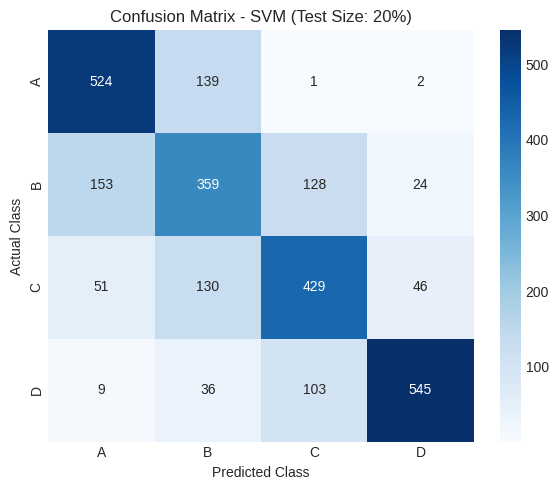


--- Classification Task (Test Size: 30%) ---
  Training Accuracy: 0.7158
  Testing Accuracy:  0.6879
  Accuracy Gap:      0.0279


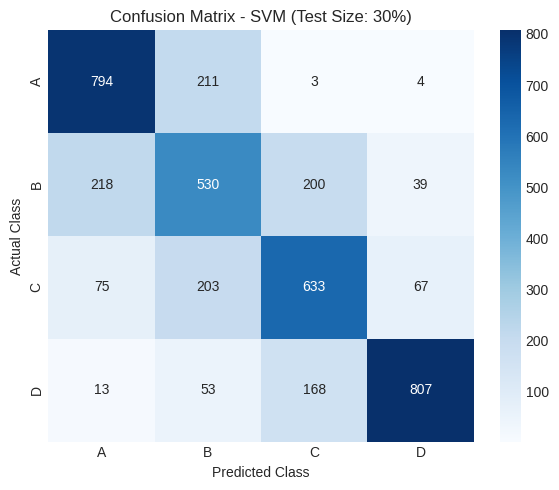


--- Classification Task (Test Size: 50%) ---
  Training Accuracy: 0.7073
  Testing Accuracy:  0.6835
  Accuracy Gap:      0.0237


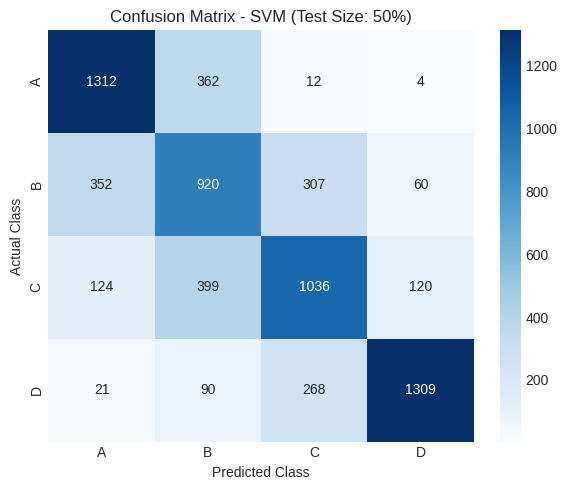



▸▸▸▸▸▸▸▸▸▸▸▸▸▸▸▸▸▸▸▸▸▸▸▸▸▸▸ REGRESSION EXPERIMENTS ◂◂◂◂◂◂◂◂◂◂◂◂◂◂◂◂◂◂◂◂◂◂◂◂◂◂◂

--- Regression Task: Predict broad_jump (Test Size: 20%) ---

🔹 Model: Linear Regression
  Training R² Score: 0.7906
  Testing R² Score:  0.7766
  R² Gap:            0.0140
  Training MSE:      332.8637
  Testing MSE:       354.8012


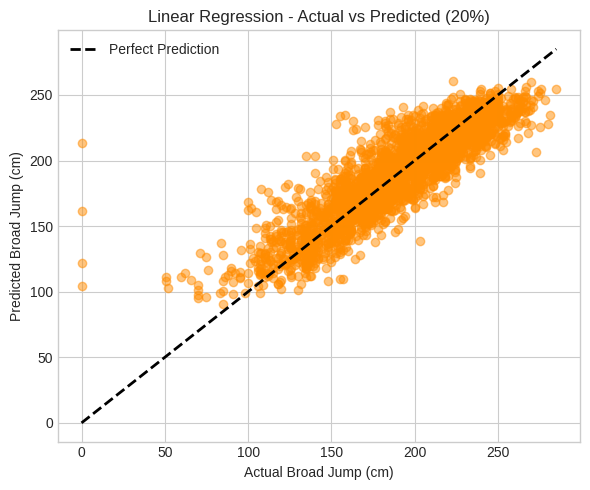


--- Regression Task: Predict broad_jump (Test Size: 30%) ---

🔹 Model: Linear Regression
  Training R² Score: 0.7897
  Testing R² Score:  0.7833
  R² Gap:            0.0064
  Training MSE:      332.4750
  Testing MSE:       348.9006


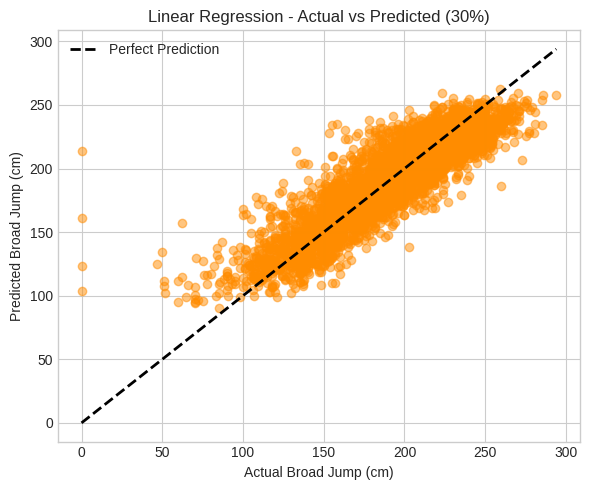


--- Regression Task: Predict broad_jump (Test Size: 50%) ---

🔹 Model: Linear Regression
  Training R² Score: 0.7896
  Testing R² Score:  0.7857
  R² Gap:            0.0038
  Training MSE:      332.0960
  Testing MSE:       342.9618


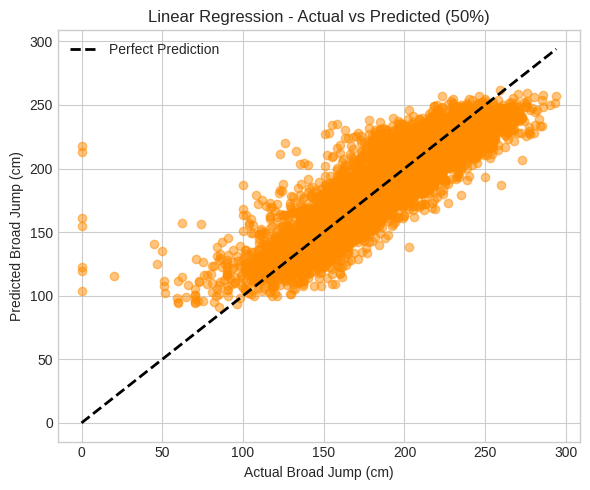



▸▸▸▸▸▸▸▸▸▸▸▸▸▸▸▸▸▸▸▸▸▸▸▸▸▸▸ CROSS-VALIDATION ◂◂◂◂◂◂◂◂◂◂◂◂◂◂◂◂◂◂◂◂◂◂◂◂◂◂◂

--- K-Fold Cross Validation (K=5) ---

🔹 Classification Task (SVM):
  K-Fold Accuracies: [0.69279582 0.70175439 0.69454817 0.68297237 0.68147872]
  Mean Accuracy:     0.6907 (+/- 0.0151)

🔹 Regression Task (Linear Regression):
  K-Fold R² Scores:  [0.77662447 0.78556225 0.7866138  0.79636062 0.79130411]
  Mean R² Score:     0.7873 (+/- 0.0131)

EXPERIMENTS COMPLETED


In [272]:
# ============================================================================
# 5. MAIN EXECUTION BLOCK
# ============================================================================

if __name__ == "__main__":

    # Load and preprocess the data
    data = load_and_preprocess_data(None)

    # Define the different test sizes required for the experiment
    splits = [0.20, 0.30, 0.50]

    print("\n" + "="*54)
    print("STARTING EXPERIMENTS")
    print("="*54)

    # Step 2: Run Classification experiments
    print("\n\n" + "▸"*27 + " CLASSIFICATION EXPERIMENTS " + "◂"*27)
    for split in splits:
        classification_task(data, split)

    # Step 3: Run Regression experiments
    print("\n\n" + "▸"*27 + " REGRESSION EXPERIMENTS " + "◂"*27)
    for split in splits:
        regression_task(data, split)

    # Step 4: Run K-Fold Cross Validation
    print("\n\n" + "▸"*27 + " CROSS-VALIDATION " + "◂"*27)
    kfold_cross_validation(data, k=5)

    print("\n" + "="*54)
    print("EXPERIMENTS COMPLETED")
    print("="*54)

In [273]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing  import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neural_network  import MLPClassifier
from sklearn.metrics         import (
    accuracy_score, classification_report, confusion_matrix
)

In [275]:
df = pd.read_csv('/content/data.csv')

# X / y / Scale ───────────────────────────────────────────────
X        = df_clean.drop(columns=['class'])
y        = df_clean['class']
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"data is ready : {X_scaled.shape}")

data is ready : (13101, 12)



  80% Train / 20% Test
  Train=10480  |  Test=2621
  Test Accuracy : 71.58%
  CV (5-Fold)   : 70.81% ± 0.40%

              precision    recall  f1-score   support

        D(1)       0.86      0.82      0.84       628
        C(2)       0.67      0.66      0.66       665
        B(3)       0.59      0.61      0.60       664
        A(4)       0.75      0.79      0.77       664

    accuracy                           0.72      2621
   macro avg       0.72      0.72      0.72      2621
weighted avg       0.72      0.72      0.72      2621



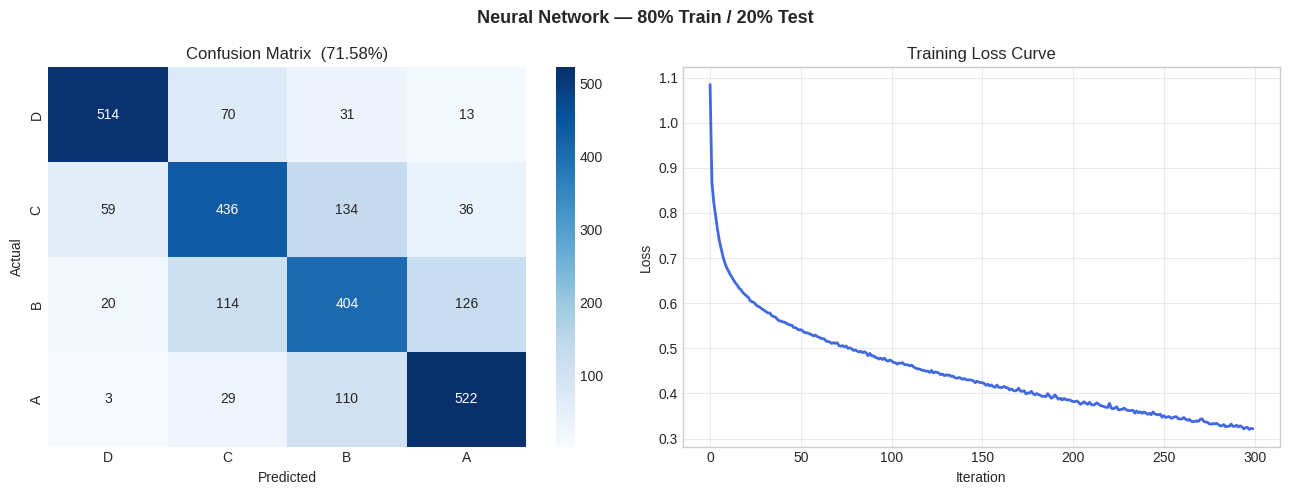


  70% Train / 30% Test
  Train=9170  |  Test=3931
  Test Accuracy : 69.78%
  CV (5-Fold)   : 70.81% ± 0.40%

              precision    recall  f1-score   support

        D(1)       0.85      0.80      0.83       943
        C(2)       0.66      0.65      0.65       997
        B(3)       0.57      0.59      0.58       995
        A(4)       0.73      0.76      0.74       996

    accuracy                           0.70      3931
   macro avg       0.70      0.70      0.70      3931
weighted avg       0.70      0.70      0.70      3931



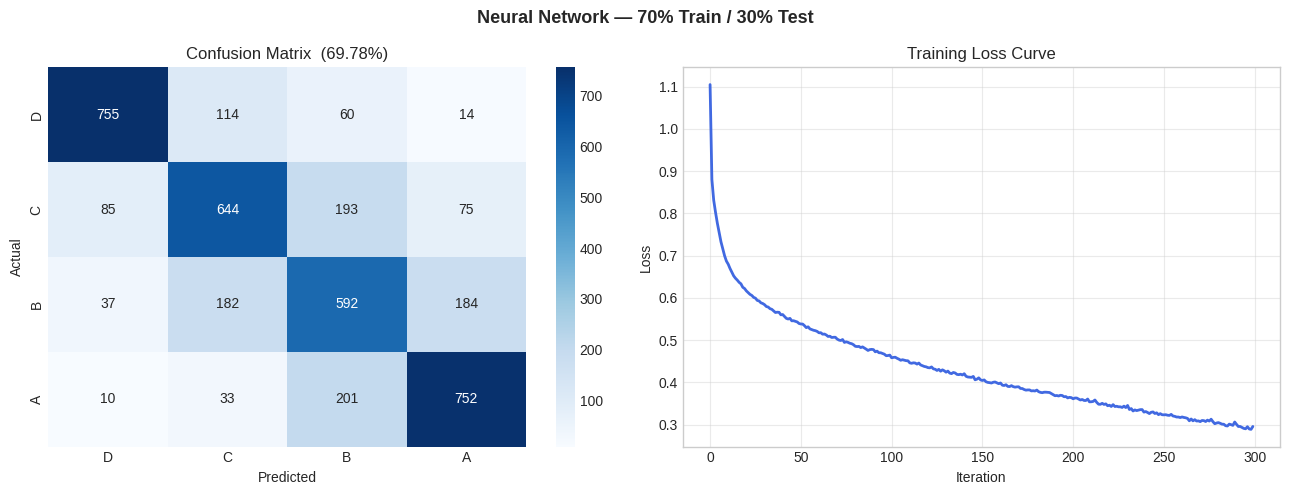


  50% Train / 50% Test
  Train=6550  |  Test=6551
  Test Accuracy : 69.36%
  CV (5-Fold)   : 70.81% ± 0.40%

              precision    recall  f1-score   support

        D(1)       0.84      0.80      0.82      1570
        C(2)       0.67      0.61      0.64      1662
        B(3)       0.57      0.57      0.57      1659
        A(4)       0.71      0.79      0.75      1660

    accuracy                           0.69      6551
   macro avg       0.70      0.70      0.69      6551
weighted avg       0.69      0.69      0.69      6551



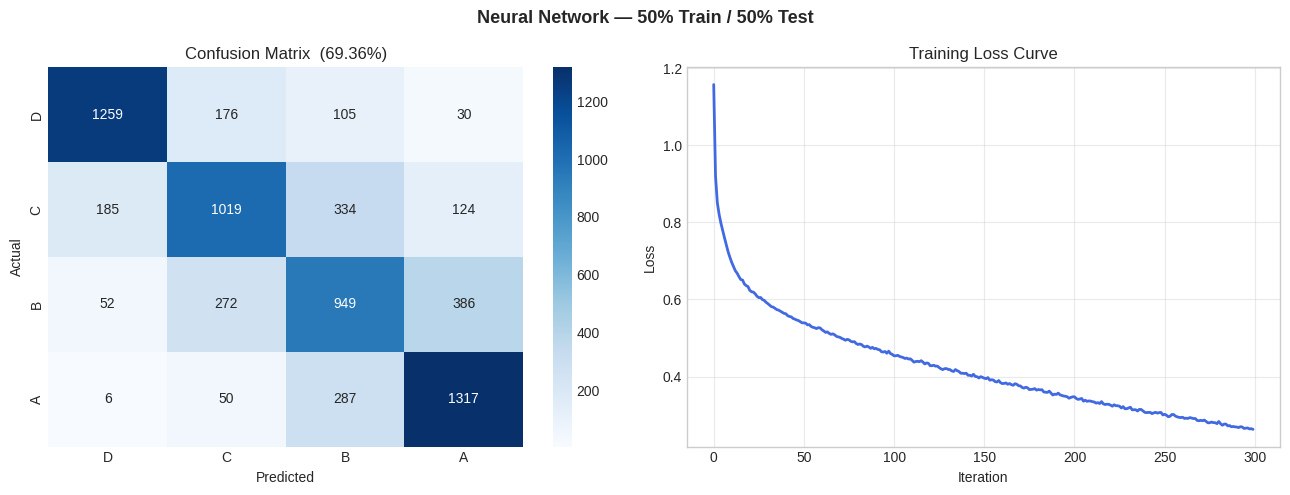

In [276]:
splits = [
    (0.20, '80% Train / 20% Test'),
    (0.30, '70% Train / 30% Test'),
    (0.50, '50% Train / 50% Test'),
]

results = []   # هنحفظ النتايج عشان نقارن في الآخر

for test_size, label in splits:

    # ── Split ────────────────────────────────────────────────
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y,
        test_size    = test_size,
        random_state = 42,
        stratify     = y
    )

    # ── Model (2 hidden layers) ───────────────────────────────
    model = MLPClassifier(
        hidden_layer_sizes = (128, 64),   # Layer1=128, Layer2=64
        activation         = 'relu',
        max_iter           = 300,
        random_state       = 42
    )
    model.fit(X_train, y_train)

    # ── Evaluate ─────────────────────────────────────────────
    y_pred   = model.predict(X_test)
    acc      = accuracy_score(y_test, y_pred)
    cv       = cross_val_score(model, X_scaled, y, cv=5, scoring='accuracy')
    results.append((label, acc, cv.mean(), cv.std()))

    # ── Print ─────────────────────────────────────────────────
    print(f"\n{'='*55}")
    print(f"  {label}")
    print(f"  Train={len(X_train)}  |  Test={len(X_test)}")
    print(f"{'='*55}")
    print(f"  Test Accuracy : {acc*100:.2f}%")
    print(f"  CV (5-Fold)   : {cv.mean()*100:.2f}% ± {cv.std()*100:.2f}%")
    print()
    print(classification_report(
        y_test, y_pred,
        target_names=['D(1)', 'C(2)', 'B(3)', 'A(4)']
    ))

    # ── Plots (Confusion Matrix + Loss Curve) ────────────────
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f'Neural Network — {label}',
                 fontsize=13, fontweight='bold')

    sns.heatmap(confusion_matrix(y_test, y_pred),
                annot=True, fmt='d', cmap='Blues',
                xticklabels=['D','C','B','A'],
                yticklabels=['D','C','B','A'],
                ax=axes[0])
    axes[0].set_title(f'Confusion Matrix  ({acc*100:.2f}%)')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')

    axes[1].plot(model.loss_curve_, color='royalblue', lw=2)
    axes[1].set_title('Training Loss Curve')
    axes[1].set_xlabel('Iteration')
    axes[1].set_ylabel('Loss')
    axes[1].grid(True, alpha=0.4)

    plt.tight_layout()
    plt.show()